# Fase 4-D - Janelas deslizantes e lag temporal: formacao do El Nino e propagacao para o Brasil

**Metodo: exclusivamente estatistico** (correlacao cruzada defasada; sem ML/redes).

Tres entregas:
1. **Formacao (semanal)** - precursor oceanico/atmosferico LIDERA a SSTA do Nino 3.4; lead em semanas.
2. **Propagacao (mensal, estratificada por estacao)** - o Nino 3.4 LIDERA a chuva do Brasil pixel-a-pixel; lag em meses ate atingir cada regiao, e o sinal (chuva +/seca -).
3. **Como atinge** - composicoes de extremos (seca <=P10 / chuva >=P90) por fase ENOS.

> **Nota de escala (resultado empirico, nao escolha arbitraria):** a chuva responde ao El Nino numa escala **sazonal-mensal**. Testada a correlacao pixel-a-pixel com anomalia **semanal**, **nenhum** pixel sobrevive a significancia de campo (FDR) - o sinal semanal e dominado por ruido meteorologico. Por isso a *formacao* (oceano, suave) usa janela **semanal**, e a *propagacao* (chuva, ruidosa) usa **mensal + estacao**. Ambas sao estatisticas e usam a mesma matriz saneada.

In [1]:
import sys, glob, re, warnings, time
from pathlib import Path
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, xarray as xr
import matplotlib.pyplot as plt
from scipy import stats
ROOT=Path.cwd()
while ROOT!=ROOT.parent and not (ROOT/'pyproject.toml').exists(): ROOT=ROOT.parent
sys.path.insert(0,str(ROOT/'scripts')); import fase4_features as F
import fase4_maps as M  # contornos IBGE (estados+regioes)
plt.rcParams.update({'figure.dpi':110,'axes.grid':True,'grid.alpha':0.3,'font.size':9})

Y0,Y1=1981,2025
PERIODO=(f'{Y0}-09-01',f'{Y1}-12-31')
WK='7D'
LAGS_FORM=range(0,53)                      # semanas (ate ~12 meses) p/ formacao
LAGS_RAIN=range(0,7)                        # meses (0..6) p/ propagacao
SEASONS={'DJF':[12,1,2],'MAM':[3,4,5],'JJA':[6,7,8],'SON':[9,10,11],'ANO':list(range(1,13))}
OUT=F.STATS/'phase4_D_semanal'; OUT.mkdir(parents=True,exist_ok=True)

def weekly_anom(s):
    w=s.resample(WK).mean(); woy=w.index.isocalendar().week
    return (w-w.groupby(woy).transform('mean'))/w.groupby(woy).transform('std').replace(0,np.nan)
def neff_scalar(x,y):
    n=len(x); r1x=pd.Series(x).autocorr(1); r1y=pd.Series(y).autocorr(1)
    if np.isnan(r1x) or np.isnan(r1y): return n
    return max(3.0,n*(1-r1x*r1y)/(1+r1x*r1y))
def corr_p(x,y):
    m=np.isfinite(x)&np.isfinite(y); x,y=x[m],y[m]
    if len(x)<24: return np.nan,np.nan
    r=np.corrcoef(x,y)[0,1]; ne=neff_scalar(x,y)
    t=r*np.sqrt(max(ne-2,1)/max(1-r**2,1e-9)); return r,2*stats.t.sf(abs(t),df=max(ne-2,1))
def fdr_mask(p,q=0.05):
    p=np.asarray(p,float); ok=np.isfinite(p); pv=p[ok]; n=pv.size
    if n==0: return np.zeros_like(p,bool)
    o=np.argsort(pv); thr=q*np.arange(1,n+1)/n; pas=pv[o]<=thr
    k=np.where(pas)[0].max()+1 if pas.any() else 0; crit=thr[k-1] if k>0 else 0.0
    out=np.zeros_like(p,bool); out[ok]=p[ok]<=crit; return out
def report(df,name): df.to_csv(OUT/f'{name}.csv',index=False); print(f'[csv: phase4_D_semanal/{name}.csv]'); return df

def load_atmo_nino34():
    """ERA5 caixa Nino3.4 (cache-aware). 1a execucao constroi o cache (~1 min)."""
    cache=F.PROC/'parquet'/'features'/'era5_nino34_atmo_cache.csv'
    if cache.exists():
        return pd.read_csv(cache,parse_dates=['time']).set_index('time')
    cols={}
    for nome,var,kind,lev in [('atm_10m_u_component_of_wind','10m_u_component_of_wind','single',None),
                              ('atm_mean_sea_level_pressure','mean_sea_level_pressure','single',None),
                              ('atm_total_column_water_vapour','total_column_water_vapour','single',None),
                              ('atm_u_component_of_wind_850hpa','u_component_of_wind','pressure',850)]:
        cols[nome]=F.era5_box_index(var,kind=kind,region='nino34',level=lev,years=range(Y0,Y1+1))
    df=pd.concat(cols,axis=1); df.index.name='time'; df.to_csv(cache); return df
print('setup ok |',PERIODO)

setup ok | ('1981-09-01', '2025-12-31')


## Parte 1 - Lag de FORMACAO (precursor LIDERA o Nino 3.4) - janela semanal

Cross-correlacao semanal: o precursor em t-L vs a SSTA do Nino 3.4 em t (precursor liderando 0-52 semanas). Reporta o lead de pico, sinal e p-valor com GL efetivo (Bretherton).

In [2]:
bb=F.load_physics_backbone(base='full').loc[PERIODO[0]:PERIODO[1]]
y=weekly_anom(bb['nino34_ssta'])
OCEANO={'WWV (agua quente)':'wwv_equatorial_pacific_m3','OHC 0-300 m':'ohc_0_300_nino34_j_m2',
        'OHC 0-700 m':'ohc_0_700_nino34_j_m2','D20 (isoterma 20C)':'d20_nino34_mean_m',
        'Inclinacao termoclina':'thermocline_tilt_m','SSH (nivel do mar)':'ssh_nino34_mean_m'}
prec={k:weekly_anom(bb[v]) for k,v in OCEANO.items() if v in bb}
atmo=load_atmo_nino34().loc[PERIODO[0]:PERIODO[1]]
ATM={'Vento zonal 10m (tau_x)':'atm_10m_u_component_of_wind','Vento zonal 850 (Walker)':'atm_u_component_of_wind_850hpa',
     'Pressao nivel mar (SOI)':'atm_mean_sea_level_pressure','Agua precipitavel (conv.)':'atm_total_column_water_vapour'}
for k,v in ATM.items():
    if v in atmo: prec[k]=weekly_anom(atmo[v])
print('precursores:',len(prec))

precursores: 10


[csv: phase4_D_semanal/lag_formacao_precursores.csv]
                precursor  lead_semanas  lead_meses  r_pico    sinal  p_efetivo signif_5pct
    Inclinacao termoclina             0         0.0   0.817 positivo     0.0000         sim
Agua precipitavel (conv.)             0         0.0   0.737 positivo     0.0000         sim
 Vento zonal 850 (Walker)             1         0.2   0.607 positivo     0.0000         sim
  Vento zonal 10m (tau_x)             1         0.2   0.501 positivo     0.0000         sim
  Pressao nivel mar (SOI)             5         1.2  -0.408 negativo     0.0000         sim
       SSH (nivel do mar)             6         1.4   0.797 positivo     0.0000         sim
              OHC 0-700 m             7         1.6   0.773 positivo     0.0000         sim
              OHC 0-300 m             8         1.8   0.801 positivo     0.0000         sim
       D20 (isoterma 20C)            17         3.9   0.666 positivo     0.0000         sim
        WWV (agua quente)  

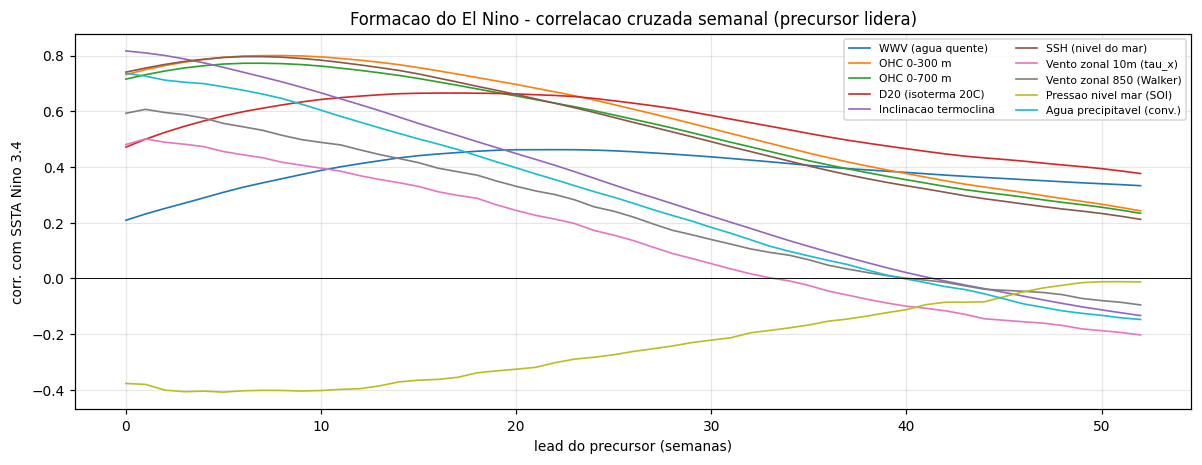

In [3]:
rows=[]; curves={}
for nome,x in prec.items():
    xa=x.reindex(y.index); best=None; cur=[]
    for L in LAGS_FORM:
        df=pd.concat([y,xa.shift(L)],axis=1).dropna()
        if len(df)<60: cur.append(np.nan); continue
        r,p=corr_p(df.iloc[:,0].values,df.iloc[:,1].values); cur.append(r)
        if best is None or abs(r)>abs(best[1]): best=(L,r,p)
    curves[nome]=cur; L,r,p=best
    rows.append((nome,L,round(L/4.345,1),round(r,3),'positivo' if r>=0 else 'negativo',round(p,4),'sim' if p<0.05 else 'nao'))
tab_form=report(pd.DataFrame(rows,columns=['precursor','lead_semanas','lead_meses','r_pico','sinal','p_efetivo','signif_5pct']).sort_values('lead_semanas'),'lag_formacao_precursores')
print(tab_form.to_string(index=False))
fig,ax=plt.subplots(figsize=(11,4.3)); xx=list(LAGS_FORM)
for nome,cur in curves.items(): ax.plot(xx,cur,lw=1.1,label=nome)
ax.axhline(0,color='k',lw=0.6); ax.set_xlabel('lead do precursor (semanas)'); ax.set_ylabel('corr. com SSTA Nino 3.4')
ax.set_title('Formacao do El Nino - correlacao cruzada semanal (precursor lidera)'); ax.legend(fontsize=7,ncol=2); plt.tight_layout(); plt.show()

## Parte 2 - PROPAGACAO para o Brasil (Nino LIDERA a chuva) - mensal, por estacao

Anomalia mensal padronizada de chuva CHIRPS por pixel (0.25 graus) correlacionada com a SSTA do Nino 3.4, com o Nino liderando 0-6 meses, **estratificado por estacao** (DJF/MAM/JJA/SON e ano-todo). Mapas de **lag de pico (meses ate atingir)**, **sinal (chuva +/seca -)** e **mascara FDR**.

In [4]:
# Cubo CHIRPS MENSAL padronizado (Brasil) + Nino mensal
LAT=F.BRAZIL_BOX['lat']; LON=F.BRAZIL_BOX['lon']; t0=time.time()
das=[xr.open_zarr(str(F.ZARR/'regridded'/f'chirps_p25_{yv}.zarr')).sel(lat=slice(*LAT),lon=slice(*LON))['precip'] for yv in range(Y0,Y1+1) if glob.glob(str(F.ZARR/'regridded'/f'chirps_p25_{yv}.zarr'))]
pr=xr.concat(das,'time').sortby('time').sel(time=slice(PERIODO[0],PERIODO[1]))
mo=pr.resample(time='MS').mean().transpose('time','lat','lon').load()
V=mo.values; tw=pd.DatetimeIndex(mo['time'].values); mm=tw.month.values
R=np.full_like(V,np.nan)
for k in range(1,13):
    i=mm==k; muu=np.nanmean(V[i],0); sg=np.nanstd(V[i],0); R[i]=(V[i]-muu)/np.where(sg>0,sg,np.nan)
lats=mo['lat'].values; lons=mo['lon'].values; land=np.isfinite(pr.isel(time=0).values)
ss=bb['nino34_ssta'].resample('MS').mean(); yv=((ss-ss.groupby(ss.index.month).transform('mean'))/ss.groupby(ss.index.month).transform('std')).reindex(tw).values
r1x=pd.Series(yv).autocorr(1)
# autocorr lag-1 por pixel (p/ Neff)
a=R[:-1]; b=R[1:]; am=a-np.nanmean(a,0); bm=b-np.nanmean(b,0)
r1y=np.nansum(am*bm,0)/np.sqrt(np.nansum(am**2,0)*np.nansum(bm**2,0))
print('cubo mensal:',R.shape,'| pixels terra:',int(land.sum()),'| t=%.1fs'%(time.time()-t0))

cubo mensal: (532, 169, 181) | pixels terra: 19431 | t=18.1s


In [5]:
# Correlacao defasada por estacao (Nino lidera 0-6 meses)
ny,nx=land.shape; results={}; summ=[]
for sname,months in SEASONS.items():
    br=np.full((ny,nx),np.nan); bl=np.full((ny,nx),np.nan)
    smask=np.isin(mm,months)
    for L in LAGS_RAIN:
        xs=pd.Series(yv).shift(L).values; m=np.isfinite(xs)&smask
        if m.sum()<24: continue
        xm=xs[m]-np.nanmean(xs[m]); Rc=R[m]-np.nanmean(R[m],0)
        num=np.nansum(xm[:,None,None]*Rc,0); den=np.sqrt(np.nansum(xm**2)*np.nansum(Rc**2,0))
        r=np.where(den>0,num/den,np.nan)
        u=np.isfinite(r)&(np.isnan(br)|(np.abs(r)>np.abs(br))); br[u]=r[u]; bl[u]=L
    nsea=int(np.isin(mm,months).sum())
    fac=(1-r1x*r1y)/(1+r1x*r1y); Neff=np.clip(nsea*fac,3,nsea)
    with np.errstate(invalid='ignore',divide='ignore'):
        tstat=br*np.sqrt((Neff-2)/(1-br**2)); bp=2*stats.t.sf(np.abs(tstat),df=np.clip(Neff-2,1,None))
    bp=np.where(land&np.isfinite(br),bp,np.nan); mask=fdr_mask(bp.ravel()).reshape(ny,nx)
    sig=mask&np.isfinite(br); results[sname]=(br,bl,bp,mask)
    summ.append((sname,int(land.sum()),int(sig.sum()),round(100*sig.sum()/land.sum(),1),
                 float(np.nanmedian(bl[sig])) if sig.any() else np.nan,
                 int((sig&(br>0)).sum()),int((sig&(br<0)).sum())))
tab=report(pd.DataFrame(summ,columns=['estacao','pixels_terra','signif_fdr','%_signif','lag_mediano_meses','chuva(+)','seca(-)']),'resumo_propagacao_por_estacao')
print(tab.to_string(index=False))
ds=xr.Dataset({f'{s}_{k}_{n}':(('lat','lon'),results[s][i]) for s in results for i,(k,n) in enumerate([('r','pico'),('lag','meses'),('p','efetivo'),('mask','fdr')])},coords={'lat':lats,'lon':lons})
ds.to_netcdf(OUT/'mapa_propagacao_brasil_por_estacao.nc'); print('[nc: mapa_propagacao_brasil_por_estacao.nc]')

[csv: phase4_D_semanal/resumo_propagacao_por_estacao.csv]
estacao  pixels_terra  signif_fdr  %_signif  lag_mediano_meses  chuva(+)  seca(-)
    DJF         19431        6718      34.6                1.0      1748     4970
    MAM         19431        4418      22.7                2.0      1821     2597
    JJA         19431        3768      19.4                1.0       321     3447
    SON         19431        8969      46.2                3.0      2426     6543
    ANO         19431       13186      67.9                2.0      3696     9490
[nc: mapa_propagacao_brasil_por_estacao.nc]


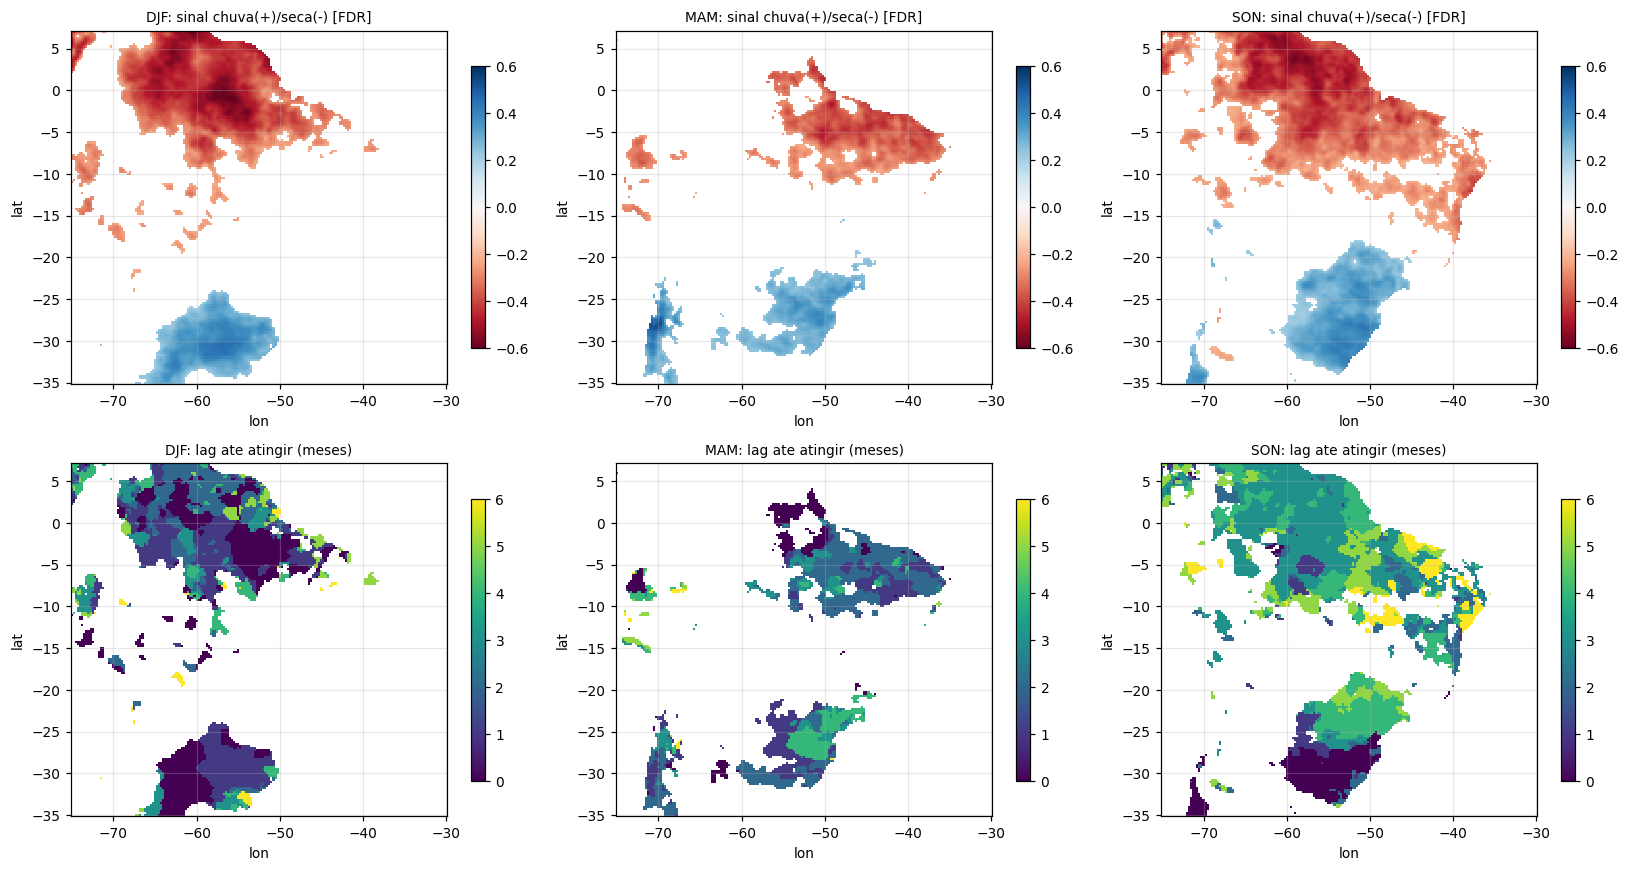

In [6]:
# Mapas: sinal e lag por estacao (so DJF, MAM, SON - as de maior sinal)
def panel(ax,Z,sig,lats,lons,cmap,vmin,vmax,title):
    Zm=np.where(sig,Z,np.nan); im=ax.pcolormesh(lons,lats,Zm,cmap=cmap,vmin=vmin,vmax=vmax,shading='auto')
    ax.set_title(title,fontsize=9); plt.colorbar(im,ax=ax,shrink=0.8); M.add_brazil(ax); ax.set_xlabel('lon'); ax.set_ylabel('lat')
fig,axes=plt.subplots(2,3,figsize=(15,8))
for j,s in enumerate(['DJF','MAM','SON']):
    br,bl,bp,mask=results[s]; sig=mask&np.isfinite(br)
    panel(axes[0,j],br,sig,lats,lons,'RdBu',-0.6,0.6,f'{s}: sinal chuva(+)/seca(-) [FDR]')
    panel(axes[1,j],bl,sig,lats,lons,'viridis',0,6,f'{s}: lag ate atingir (meses)')
plt.tight_layout(); plt.show()

## Parte 3 - *Como* atinge: composicoes de extremos por fase El Nino (mensal)

Anomalia media mensal de chuva em meses de El Nino (SSTA>=0.5) menos demais meses, e a fracao de meses em **seca extrema (<=P10)** e **chuva extrema (>=P90)** durante o El Nino.

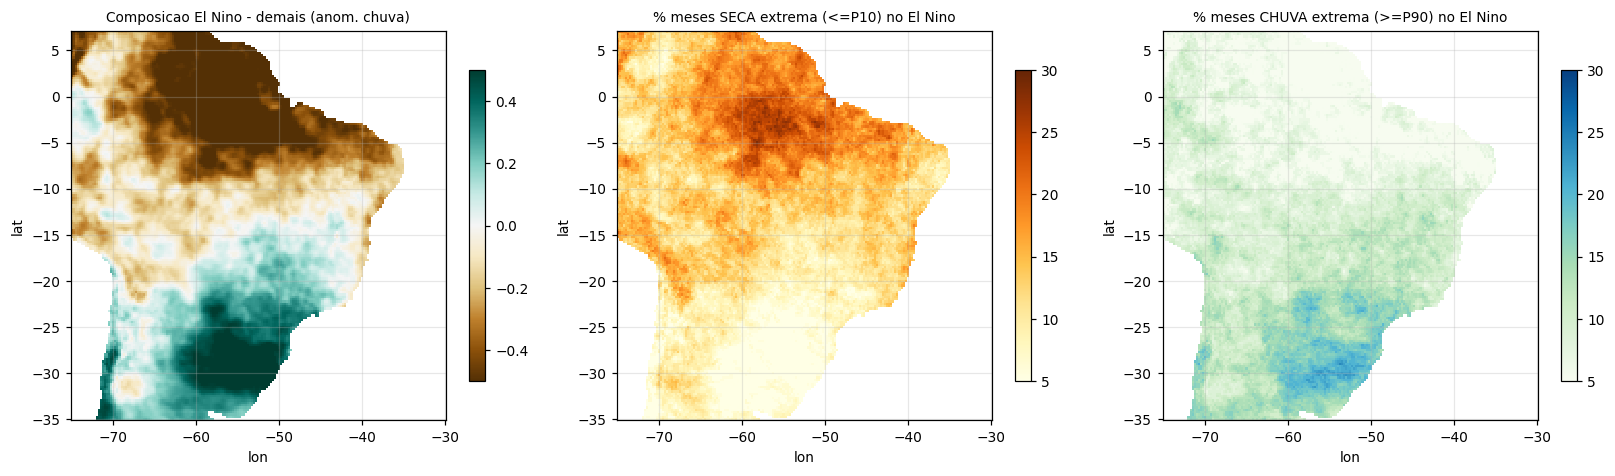

composicoes salvas.


In [7]:
elnino=(ss.reindex(tw).values>=0.5)
comp=np.nanmean(R[elnino],0)-np.nanmean(R[~elnino],0)
p10=np.nanpercentile(R,10,0); p90=np.nanpercentile(R,90,0)
fseca=np.nanmean(R[elnino]<=p10[None],0)*100; fchuva=np.nanmean(R[elnino]>=p90[None],0)*100
xr.Dataset({'composicao_elnino':(('lat','lon'),comp),'pct_meses_seca_extrema':(('lat','lon'),fseca),
            'pct_meses_chuva_extrema':(('lat','lon'),fchuva)},coords={'lat':lats,'lon':lons}).to_netcdf(OUT/'composicoes_extremos_elnino.nc')
fig,axes=plt.subplots(1,3,figsize=(15,4.4))
for ax,Z,cmap,vmin,vmax,tit in [(axes[0],np.where(land,comp,np.nan),'BrBG',-0.5,0.5,'Composicao El Nino - demais (anom. chuva)'),
                                 (axes[1],np.where(land,fseca,np.nan),'YlOrBr',5,30,'% meses SECA extrema (<=P10) no El Nino'),
                                 (axes[2],np.where(land,fchuva,np.nan),'GnBu',5,30,'% meses CHUVA extrema (>=P90) no El Nino')]:
    im=ax.pcolormesh(lons,lats,Z,cmap=cmap,vmin=vmin,vmax=vmax,shading='auto'); plt.colorbar(im,ax=ax,shrink=0.8); M.add_brazil(ax); ax.set_title(tit,fontsize=9); ax.set_xlabel('lon'); ax.set_ylabel('lat')
plt.tight_layout(); plt.show(); print('composicoes salvas.')

## Interpretacao e limites

**Formacao (Parte 1, semanal):** `lag_formacao_precursores.csv` da o lead de pico de cada precursor. Espera-se conteudo de calor/WWV/D20 liderando varios meses (recarga) e o vento zonal liderando poucas semanas (acoplamento rapido). Aqui a janela **semanal** e adequada porque as variaveis oceanicas sao suaves.

**Propagacao (Parte 2, mensal/estacao):** `mapa_propagacao_brasil_por_estacao.nc` da, por pixel e estacao, quantos **meses** o sinal do Nino leva para atingir a chuva, o sinal (chuva+/seca-) e a mascara FDR. So pixels FDR<5% devem ser lidos. A estratificacao sazonal e essencial: o sinal se concentra em estacoes especificas (ex.: Sul umido em DJF/SON; Norte/NE seco).

**Como atinge (Parte 3):** `composicoes_extremos_elnino.nc` mostra onde o El Nino aumenta a frequencia de meses em seca ou chuva extrema.

**Limites honestos:** (1) e **triagem estatistica** - associacao/defasagem/significancia, nao causalidade nem previsao operacional (isso e a Fase 5); (2) a chuva **nao** tem lag semanal robusto - testado e nulo sob FDR; a escala fisica da teleconexao e mensal-sazonal; (3) a janela semanal e cientificamente valida para os **precursores oceanicos**, que e onde o lag de formacao realmente vive.